In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# **CNN PROJECT**

**Imports and Dataset Loading**

In [2]:
# Cell 1: Imports and dataset loading

import numpy as np
import matplotlib.pyplot as plt
import torch
import torchvision

from torchvision.datasets import OxfordIIITPet

print("PyTorch version:", torch.__version__)
print("Torchvision version:", torchvision.__version__)

# Downloads into ./data/oxford-iiit-pet.
# Use split="trainval" for the provided training/validation portion.
dataset = OxfordIIITPet(
    root="./data",
    split="trainval",
    target_types="segmentation",
    download=True,
)

print(f"Number of samples: {len(dataset)}")

PyTorch version: 2.10.0+cu128
Torchvision version: 0.25.0+cu128


100%|██████████| 792M/792M [00:30<00:00, 25.8MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 12.2MB/s]


Number of samples: 3680


**Display several image/mask pairs and inspect their values**

Sample 0
  PIL image size (width, height): (394, 500)
  PIL mask size  (width, height): (394, 500)
  Image array shape (H, W, C):   (500, 394, 3)
  Mask array shape  (H, W):      (500, 394)
  Unique mask values:            [1 2 3]

Sample 100
  PIL image size (width, height): (333, 500)
  PIL mask size  (width, height): (333, 500)
  Image array shape (H, W, C):   (500, 333, 3)
  Mask array shape  (H, W):      (500, 333)
  Unique mask values:            [1 2 3]

Sample 500
  PIL image size (width, height): (500, 334)
  PIL mask size  (width, height): (500, 334)
  Image array shape (H, W, C):   (334, 500, 3)
  Mask array shape  (H, W):      (334, 500)
  Unique mask values:            [1 2 3]

Sample 1000
  PIL image size (width, height): (500, 375)
  PIL mask size  (width, height): (500, 375)
  Image array shape (H, W, C):   (375, 500, 3)
  Mask array shape  (H, W):      (375, 500)
  Unique mask values:            [1 2 3]



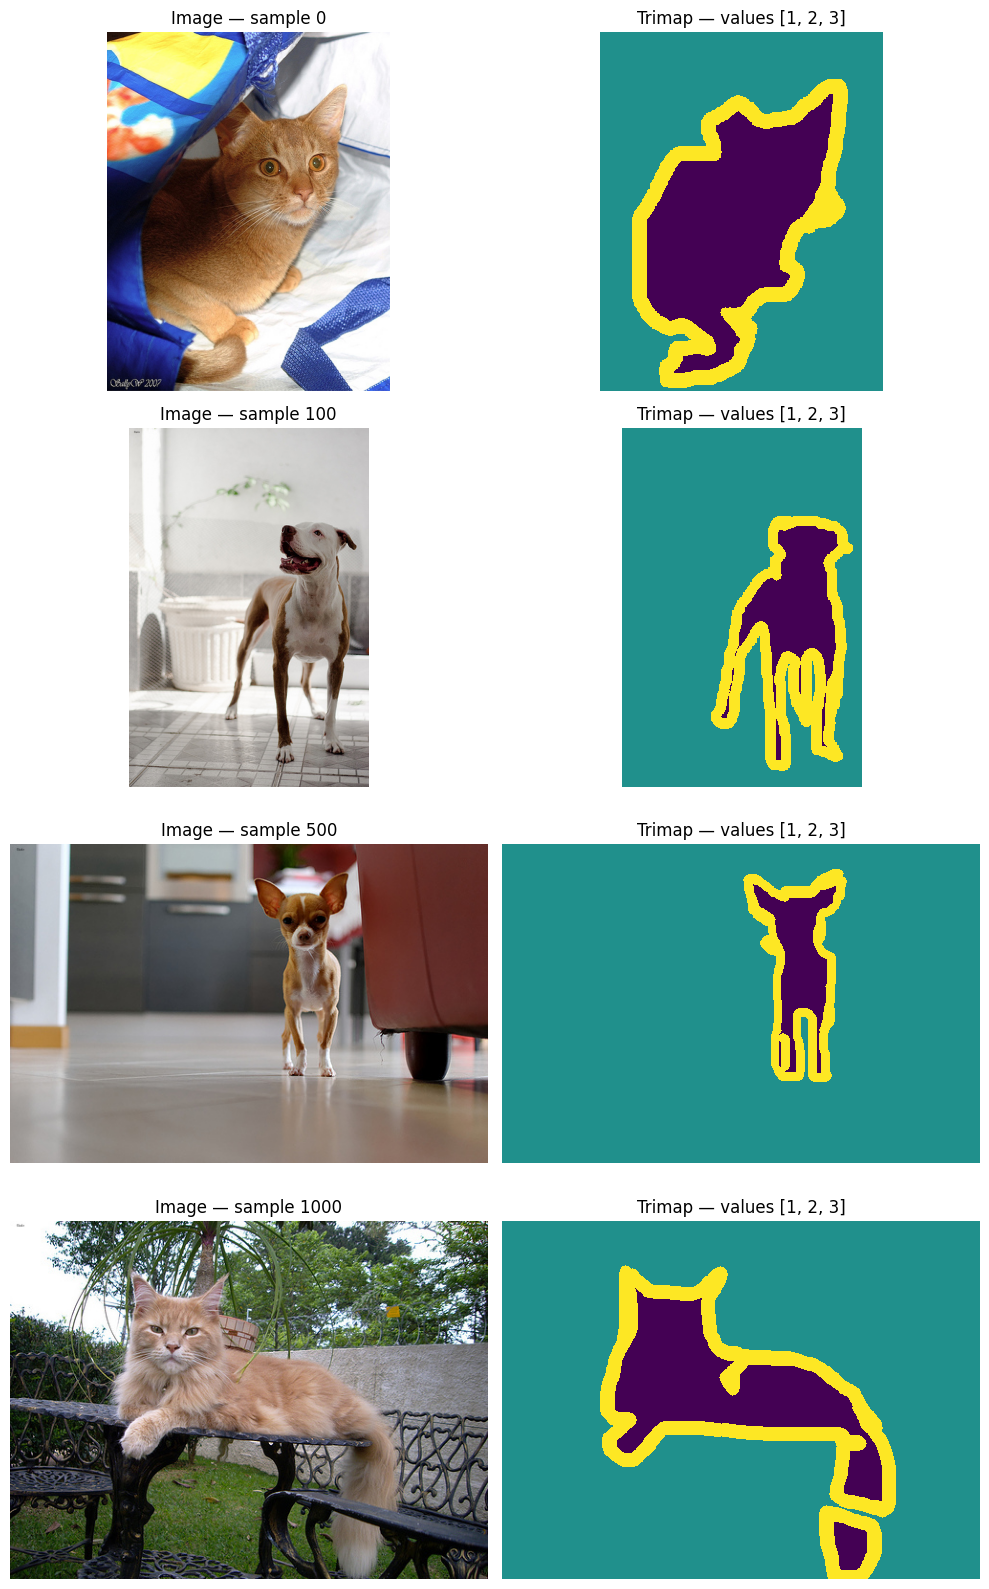

In [3]:
# Cell 2: Display several image/mask pairs and inspect their values

sample_indices = [0, 100, 500, 1000]

fig, axes = plt.subplots(
    nrows=len(sample_indices),
    ncols=2,
    figsize=(10, 4 * len(sample_indices)),
)

for row, index in enumerate(sample_indices):
    # Both objects are PIL images because no transforms were supplied.
    image, mask = dataset[index]

    # Convert to NumPy only for inspection and plotting.
    image_array = np.array(image)
    mask_array = np.array(mask)

    print(f"Sample {index}")
    print(f"  PIL image size (width, height): {image.size}")
    print(f"  PIL mask size  (width, height): {mask.size}")
    print(f"  Image array shape (H, W, C):   {image_array.shape}")
    print(f"  Mask array shape  (H, W):      {mask_array.shape}")
    print(f"  Unique mask values:            {np.unique(mask_array)}")
    print()

    axes[row, 0].imshow(image_array)
    axes[row, 0].set_title(f"Image — sample {index}")
    axes[row, 0].axis("off")

    axes[row, 1].imshow(
        mask_array,
        cmap="viridis",
        vmin=1,
        vmax=3,
        interpolation="nearest",
    )
    axes[row, 1].set_title(
        f"Trimap — values {np.unique(mask_array).tolist()}"
    )
    axes[row, 1].axis("off")

plt.tight_layout()
plt.show()

**Preprocessing Dataset**

* Interpolation

In [4]:
# Cell 3: Preprocessing Dataset

from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import functional as TF
from torchvision.transforms import InterpolationMode


class BinaryPetDataset(Dataset):
    """Wrap the existing Oxford-IIIT Pet dataset for binary segmentation."""

    def __init__(self, base_dataset):
        self.base_dataset = base_dataset

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, index):
        image, mask = self.base_dataset[index]

        # Ensure every input has three RGB channels.
        image = image.convert("RGB")

        # Resize images with bilinear interpolation.
        image = TF.resize(
            image,
            size=[128, 128],
            interpolation=InterpolationMode.BILINEAR,
            antialias=True,
        )

        # Resize masks with nearest-neighbor interpolation to preserve labels.
        mask = TF.resize(
            mask,
            size=[128, 128],
            interpolation=InterpolationMode.NEAREST,
        )

        # Converts the image to float32 [3, 128, 128] in the range [0, 1].
        image_tensor = TF.to_tensor(image)

        # Convert the mask to a long tensor [128, 128].
        mask_array = np.array(mask, dtype=np.int64, copy=True)
        mask_tensor = torch.from_numpy(mask_array)

        # Binary conversion:
        # 1 (pet) and 3 (border) -> 1
        # 2 (background)         -> 0
        mask_tensor = (
            (mask_tensor == 1) | (mask_tensor == 3)
        ).long()

        assert image_tensor.shape == (3, 128, 128)
        assert mask_tensor.shape == (128, 128)

        return image_tensor, mask_tensor


binary_dataset = BinaryPetDataset(dataset)

**DataLoader**

In [5]:
# Cell 4: DataLoader

generator = torch.Generator().manual_seed(42)

train_loader = DataLoader(
    binary_dataset,
    batch_size=8,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available(),
    generator=generator,
)

images, masks = next(iter(train_loader))

print("Images:", images.shape)
print("Masks: ", masks.shape)
print("Unique mask values:", torch.unique(masks).tolist())
print("Image value range:", images.min().item(), "to", images.max().item())

Images: torch.Size([8, 3, 128, 128])
Masks:  torch.Size([8, 128, 128])
Unique mask values: [0, 1]
Image value range: 0.003921568859368563 to 1.0


**Visualize one preprocessed sample**

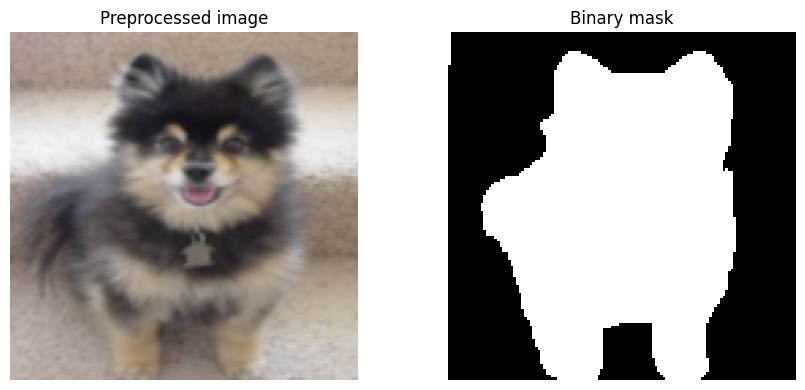

In [6]:
# Cell 5: Visualize one preprocessed sample

image = images[0].permute(1, 2, 0).cpu().numpy()
mask = masks[0].cpu().numpy()

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].imshow(image)
axes[0].set_title("Preprocessed image")
axes[0].axis("off")

axes[1].imshow(
    mask,
    cmap="gray",
    vmin=0,
    vmax=1,
    interpolation="nearest",
)
axes[1].set_title("Binary mask")
axes[1].axis("off")

plt.tight_layout()
plt.show()

**Tiny U-Net architecture**

* What is this idea of having an putting parenthesis after a attribute
* Decoder understanding (up, cat, decoder)
* Use all decoders?

In [7]:
# Cell 6: Tiny U-Net architecture

import torch
import torch.nn as nn


class ConvBlock(nn.Module):
    """Two convolution layers, each followed by BatchNorm and ReLU."""

    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.block = nn.Sequential(
            nn.Conv2d(
                in_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),

            nn.Conv2d(
                out_channels,
                out_channels,
                kernel_size=3,
                padding=1,
                bias=False,
            ),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class TinyUNet(nn.Module):
    """
    Small U-Net for two-class semantic segmentation.

    Input:  [B, 3, H, W]
    Output: [B, 2, H, W] raw logits
    """

    def __init__(
        self,
        in_channels=3,
        num_classes=2,
        base_channels=32,
        bottleneck_dropout=0.2,
    ):
        super().__init__()

        c = base_channels

        # Encoder
        self.encoder1 = ConvBlock(in_channels, c)
        self.encoder2 = ConvBlock(c, c * 2)
        self.encoder3 = ConvBlock(c * 2, c * 4)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        # Bottleneck
        self.bottleneck = ConvBlock(c * 4, c * 8)
        self.dropout = nn.Dropout2d(bottleneck_dropout)

        # Decoder
        self.up3 = nn.ConvTranspose2d(c * 8, c * 4, kernel_size=2, stride=2)
        self.decoder3 = ConvBlock(c * 8, c * 4)

        self.up2 = nn.ConvTranspose2d(c * 4, c * 2, kernel_size=2, stride=2)
        self.decoder2 = ConvBlock(c * 4, c * 2)

        self.up1 = nn.ConvTranspose2d(c * 2, c, kernel_size=2, stride=2)
        self.decoder1 = ConvBlock(c * 2, c)

        # One raw logit per class at every pixel.
        self.output_layer = nn.Conv2d(c, num_classes, kernel_size=1)

    def forward(self, x):
        if x.ndim != 4 or x.shape[1] != 3:
            raise ValueError(f"Expected [B, 3, H, W], received {x.shape}")

        # Three pooling operations require dimensions divisible by 8.
        if x.shape[-2] % 8 != 0 or x.shape[-1] % 8 != 0:
            raise ValueError("Image height and width must be divisible by 8.")

        # Encoder
        e1 = self.encoder1(x)          # [B, 32, 128, 128]
        e2 = self.encoder2(self.pool(e1))  # [B, 64, 64, 64]
        e3 = self.encoder3(self.pool(e2))  # [B, 128, 32, 32]

        # Bottleneck
        b = self.bottleneck(self.pool(e3))  # [B, 256, 16, 16]
        b = self.dropout(b)

        # Decoder with skip connection from encoder3.
        d3 = self.up3(b)                    # [B, 128, 32, 32]
        d3 = torch.cat([d3, e3], dim=1)    # [B, 256, 32, 32]
        d3 = self.decoder3(d3)              # [B, 128, 32, 32]

        # Skip connection from encoder2.
        d2 = self.up2(d3)                   # [B, 64, 64, 64]
        d2 = torch.cat([d2, e2], dim=1)    # [B, 128, 64, 64]
        d2 = self.decoder2(d2)              # [B, 64, 64, 64]

        # Skip connection from encoder1.
        d1 = self.up1(d2)                   # [B, 32, 128, 128]
        d1 = torch.cat([d1, e1], dim=1)    # [B, 64, 128, 128]
        d1 = self.decoder1(d1)              # [B, 32, 128, 128]

        # No sigmoid or softmax: CrossEntropyLoss expects raw logits.
        logits = self.output_layer(d1)      # [B, 2, 128, 128]

        return logits

**Device setup and forward-pass smoke test**

* next and iter need help
* Need more review with .eval and .inference_mode
* what is requires_grad

In [8]:
# Cell 7: Device setup and forward-pass smoke test

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = TinyUNet(
    in_channels=3,
    num_classes=2,
    base_channels=32,
    bottleneck_dropout=0.2,
).to(device)

images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

# Evaluation mode avoids updating BatchNorm statistics during the smoke test.
model.eval()

with torch.inference_mode():
    outputs = model(images)

print("Device: ", device)
print("Images: ", images.shape)
print("Outputs:", outputs.shape)
print("Masks:  ", masks.shape)

expected_shape = (images.shape[0], 2, 128, 128)

assert outputs.shape == expected_shape, (
    f"Expected output shape {expected_shape}, received {outputs.shape}"
)
assert masks.shape == (images.shape[0], 128, 128)
assert masks.dtype == torch.long
assert torch.isfinite(outputs).all(), "Model produced NaN or infinite logits."

trainable_parameters = sum(
    parameter.numel()
    for parameter in model.parameters()
    if parameter.requires_grad
)

print(f"Trainable parameters: {trainable_parameters:,}")
print("Forward-pass smoke test passed.")

Device:  cuda
Images:  torch.Size([8, 3, 128, 128])
Outputs: torch.Size([8, 2, 128, 128])
Masks:   torch.Size([8, 128, 128])
Trainable parameters: 1,927,042
Forward-pass smoke test passed.


**Set up the single-batch overfit test**

In [9]:
# Cell 8: Set up the single-batch overfit test

import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create a fresh model specifically for this debugging test.
# Dropout is disabled to make memorization more deterministic.
overfit_model = TinyUNet(
    in_channels=3,
    num_classes=2,
    base_channels=32,
    bottleneck_dropout=0.0,
).to(device)

# CrossEntropyLoss expects:
# logits: [B, 2, H, W]
# labels: [B, H, W] with dtype torch.long
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    overfit_model.parameters(),
    lr=1e-3,
)

# Grab one batch once. This exact batch is reused for all 100 steps.
images, masks = next(iter(train_loader))
images = images.to(device)
masks = masks.to(device)

assert images.shape[1:] == (3, 128, 128)
assert masks.shape[1:] == (128, 128)
assert masks.dtype == torch.long

print("Device:", device)
print("Fixed image batch:", images.shape)
print("Fixed mask batch: ", masks.shape)

Device: cuda
Fixed image batch: torch.Size([8, 3, 128, 128])
Fixed mask batch:  torch.Size([8, 128, 128])


**Train repeatedly on the same fixed batch**

* 3d and 6f thing
* Grandient accumulation
* learn adam optimizer
* Learn the autograd and other grad

In [10]:
# Cell 9: Train repeatedly on the same fixed batch

overfit_model.train()
losses = []

for step in range(1, 101):
    # Clear gradients left over from the previous step.
    optimizer.zero_grad()

    # Raw logits—do not apply softmax before CrossEntropyLoss.
    outputs = overfit_model(images)

    # Compare each pixel's two class logits with its integer class label.
    loss = criterion(outputs, masks)

    # Compute gradients and update the model weights.
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if step % 10 == 0:
        print(f"Step {step:3d}/100 | Loss: {loss.item():.6f}")

starting_loss = losses[0]
final_loss = losses[-1]
percent_decrease = (
    (starting_loss - final_loss) / starting_loss
) * 100

print(f"\nStarting loss:   {starting_loss:.6f}")
print(f"Final loss:      {final_loss:.6f}")
print(f"Percent decrease: {percent_decrease:.2f}%")

assert final_loss < starting_loss, (
    "The final loss was not lower than the starting loss."
)

Step  10/100 | Loss: 0.339316
Step  20/100 | Loss: 0.159881
Step  30/100 | Loss: 0.107512
Step  40/100 | Loss: 0.079011
Step  50/100 | Loss: 0.062181
Step  60/100 | Loss: 0.053294
Step  70/100 | Loss: 0.041420
Step  80/100 | Loss: 0.034946
Step  90/100 | Loss: 0.029936
Step 100/100 | Loss: 0.024415

Starting loss:   0.758751
Final loss:      0.024415
Percent decrease: 96.78%


**Plot the optimization curve**

* figure vs subplot

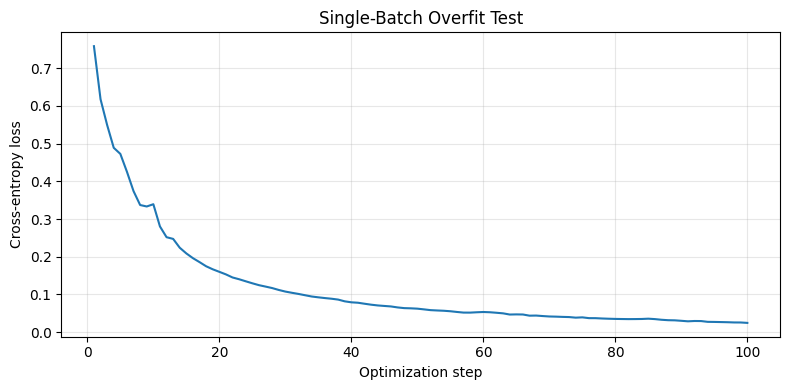

In [11]:
# Cell 10: Plot the optimization curve

plt.figure(figsize=(8, 4))
plt.plot(range(1, len(losses)+1), losses)
plt.xlabel("Optimization step")
plt.ylabel("Cross-entropy loss")
plt.title("Single-Batch Overfit Test")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**Evaluate the memorized batch**

* Inference mode vs eval
* Eval then inference mode?
* .item

In [12]:
# Cell 11: Evaluate the memorized batch

overfit_model.eval()

with torch.inference_mode():
    outputs = overfit_model(images)
    predictions = outputs.argmax(dim=1)

# Pixel accuracy is useful for debugging, but can be inflated by background.
pixel_accuracy = (predictions == masks).float().mean().item()

# Foreground IoU gives a more informative segmentation check.
intersection = ((predictions == 1) & (masks == 1)).sum()
union = ((predictions == 1) | (masks == 1)).sum()
foreground_iou = (
    intersection.float() / union.clamp_min(1)
).item()

print(f"Fixed-batch pixel accuracy: {pixel_accuracy:.2%}")
print(f"Fixed-batch foreground IoU: {foreground_iou:.2%}")

Fixed-batch pixel accuracy: 99.53%
Fixed-batch foreground IoU: 98.97%


# Full training loop with train/validation split

In [13]:
# ============================================================
# Milestone: Full training loop with train/validation split
# ============================================================

import torch
import torch.nn as nn
from torch.utils.data import random_split, DataLoader
import matplotlib.pyplot as plt

# -----------------------------
# 1. Reproducible train/val split
# -----------------------------
split_generator = torch.Generator().manual_seed(42)

train_size = int(0.8 * len(binary_dataset))
val_size = len(binary_dataset) - train_size

train_dataset, val_dataset = random_split(
    binary_dataset,
    [train_size, val_size],
    generator=split_generator
)

print(f"Training samples: {len(train_dataset)}")
print(f"Validation samples: {len(val_dataset)}")

# -----------------------------
# 2. DataLoaders
# -----------------------------
batch_size = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2,
    pin_memory=torch.cuda.is_available()
)

# -----------------------------
# 3. Fresh model, loss, optimizer
# -----------------------------
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

model = TinyUNet(
    in_channels=3,
    num_classes=2,
    base_channels=32
).to(device)

# CrossEntropyLoss expects:
# outputs: raw logits [B, 2, 128, 128]
# masks: integer class labels [B, 128, 128]
# Do NOT apply softmax before CrossEntropyLoss.
criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

Training samples: 2944
Validation samples: 736
Using device: cuda


Wait so what is the point of this? (down below)

In [14]:
# ============================================================
# 4. Segmentation metrics helper
# ============================================================

def compute_segmentation_metrics(outputs, masks):
    """
    outputs: raw logits, shape [B, 2, 128, 128]
    masks: integer labels, shape [B, 128, 128]

    Returns:
        pixel_accuracy: fraction of correctly classified pixels
        foreground_iou: IoU for class 1, pet/border
    """

    # argmax(dim=1) chooses the class with the highest logit at each pixel.
    # This converts [B, 2, H, W] logits into [B, H, W] predicted masks.
    predictions = outputs.argmax(dim=1)

    # Pixel accuracy: how many pixels match the ground truth?
    pixel_accuracy = (predictions == masks).float().mean()

    # Foreground IoU for class 1
    pred_foreground = predictions == 1
    true_foreground = masks == 1

    intersection = (pred_foreground & true_foreground).sum()
    union = (pred_foreground | true_foreground).sum().clamp_min(1)

    foreground_iou = intersection.float() / union.float()

    return pixel_accuracy.item(), foreground_iou.item()

In [15]:
# ============================================================
# 5. Full training loop
# ============================================================

num_epochs = 5

history = {
    "train_loss": [],
    "val_loss": [],
    "val_pixel_accuracy": [],
    "val_foreground_iou": []
}

best_val_iou = -1.0
best_epoch = 0
best_model_path = "/kaggle/working/best_tiny_unet_oxford_pet.pth"

for epoch in range(1, num_epochs + 1):

    # -----------------------------
    # Training phase
    # -----------------------------
    # model.train() enables training behavior such as BatchNorm updates
    # and Dropout randomness if the model uses Dropout.
    model.train()

    train_loss_total = 0.0
    train_samples = 0

    for images, masks in train_loader:
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, masks)

        loss.backward()
        optimizer.step()

        batch_size_actual = images.size(0)
        train_loss_total += loss.item() * batch_size_actual
        train_samples += batch_size_actual

    avg_train_loss = train_loss_total / train_samples

    # -----------------------------
    # Validation phase
    # -----------------------------
    # model.eval() disables training-specific behavior.
    # torch.inference_mode() saves memory and computation because
    # we do not need gradients during validation.
    model.eval()

    val_loss_total = 0.0
    val_acc_total = 0.0
    val_iou_total = 0.0
    val_samples = 0

    with torch.inference_mode():
        for images, masks in val_loader:
            images = images.to(device)
            masks = masks.to(device)

            outputs = model(images)
            loss = criterion(outputs, masks)

            pixel_acc, foreground_iou = compute_segmentation_metrics(outputs, masks)

            batch_size_actual = images.size(0)
            val_loss_total += loss.item() * batch_size_actual
            val_acc_total += pixel_acc * batch_size_actual
            val_iou_total += foreground_iou * batch_size_actual
            val_samples += batch_size_actual

    avg_val_loss = val_loss_total / val_samples
    avg_val_acc = val_acc_total / val_samples
    avg_val_iou = val_iou_total / val_samples

    history["train_loss"].append(avg_train_loss)
    history["val_loss"].append(avg_val_loss)
    history["val_pixel_accuracy"].append(avg_val_acc)
    history["val_foreground_iou"].append(avg_val_iou)

    # Save the best model based on validation foreground IoU
    if avg_val_iou > best_val_iou:
        best_val_iou = avg_val_iou
        best_epoch = epoch
    
        torch.save(model.state_dict(), best_model_path)
    
        print(
            f"New best model saved! "
            f"Epoch: {best_epoch}, "
            f"Val Foreground IoU: {best_val_iou:.4f}"
        )

    print(
        f"Epoch [{epoch}/{num_epochs}] | "
        f"Train Loss: {avg_train_loss:.4f} | "
        f"Val Loss: {avg_val_loss:.4f} | "
        f"Val Pixel Acc: {avg_val_acc:.4f} | "
        f"Val Foreground IoU: {avg_val_iou:.4f}"
    )

print("\nBest model summary:")
print(f"Best epoch: {best_epoch}")
print(f"Best validation foreground IoU: {best_val_iou:.4f}")
print(f"Checkpoint path: {best_model_path}")

New best model saved! Epoch: 1, Val Foreground IoU: 0.6449
Epoch [1/5] | Train Loss: 0.4662 | Val Loss: 0.4151 | Val Pixel Acc: 0.8095 | Val Foreground IoU: 0.6449
New best model saved! Epoch: 2, Val Foreground IoU: 0.6532
Epoch [2/5] | Train Loss: 0.3762 | Val Loss: 0.3768 | Val Pixel Acc: 0.8347 | Val Foreground IoU: 0.6532
New best model saved! Epoch: 3, Val Foreground IoU: 0.7199
Epoch [3/5] | Train Loss: 0.3379 | Val Loss: 0.3308 | Val Pixel Acc: 0.8618 | Val Foreground IoU: 0.7199
New best model saved! Epoch: 4, Val Foreground IoU: 0.7388
Epoch [4/5] | Train Loss: 0.3094 | Val Loss: 0.2891 | Val Pixel Acc: 0.8784 | Val Foreground IoU: 0.7388
New best model saved! Epoch: 5, Val Foreground IoU: 0.7398
Epoch [5/5] | Train Loss: 0.2881 | Val Loss: 0.2874 | Val Pixel Acc: 0.8781 | Val Foreground IoU: 0.7398

Best model summary:
Best epoch: 5
Best validation foreground IoU: 0.7398
Checkpoint path: /kaggle/working/best_tiny_unet_oxford_pet.pth


In [16]:
import os

print("Checkpoint exists:", os.path.exists(best_model_path))
print("Files in /kaggle/working:")
print(os.listdir("/kaggle/working"))

Checkpoint exists: True
Files in /kaggle/working:
['__notebook__.ipynb', 'data', 'best_tiny_unet_oxford_pet.pth']


**Prediction Visualization + Error Analysis**

Example 1: Pixel Acc = 0.8769, Foreground IoU = 0.8051
Example 2: Pixel Acc = 0.7819, Foreground IoU = 0.5396
Example 3: Pixel Acc = 0.9634, Foreground IoU = 0.8192
Example 4: Pixel Acc = 0.9040, Foreground IoU = 0.8738


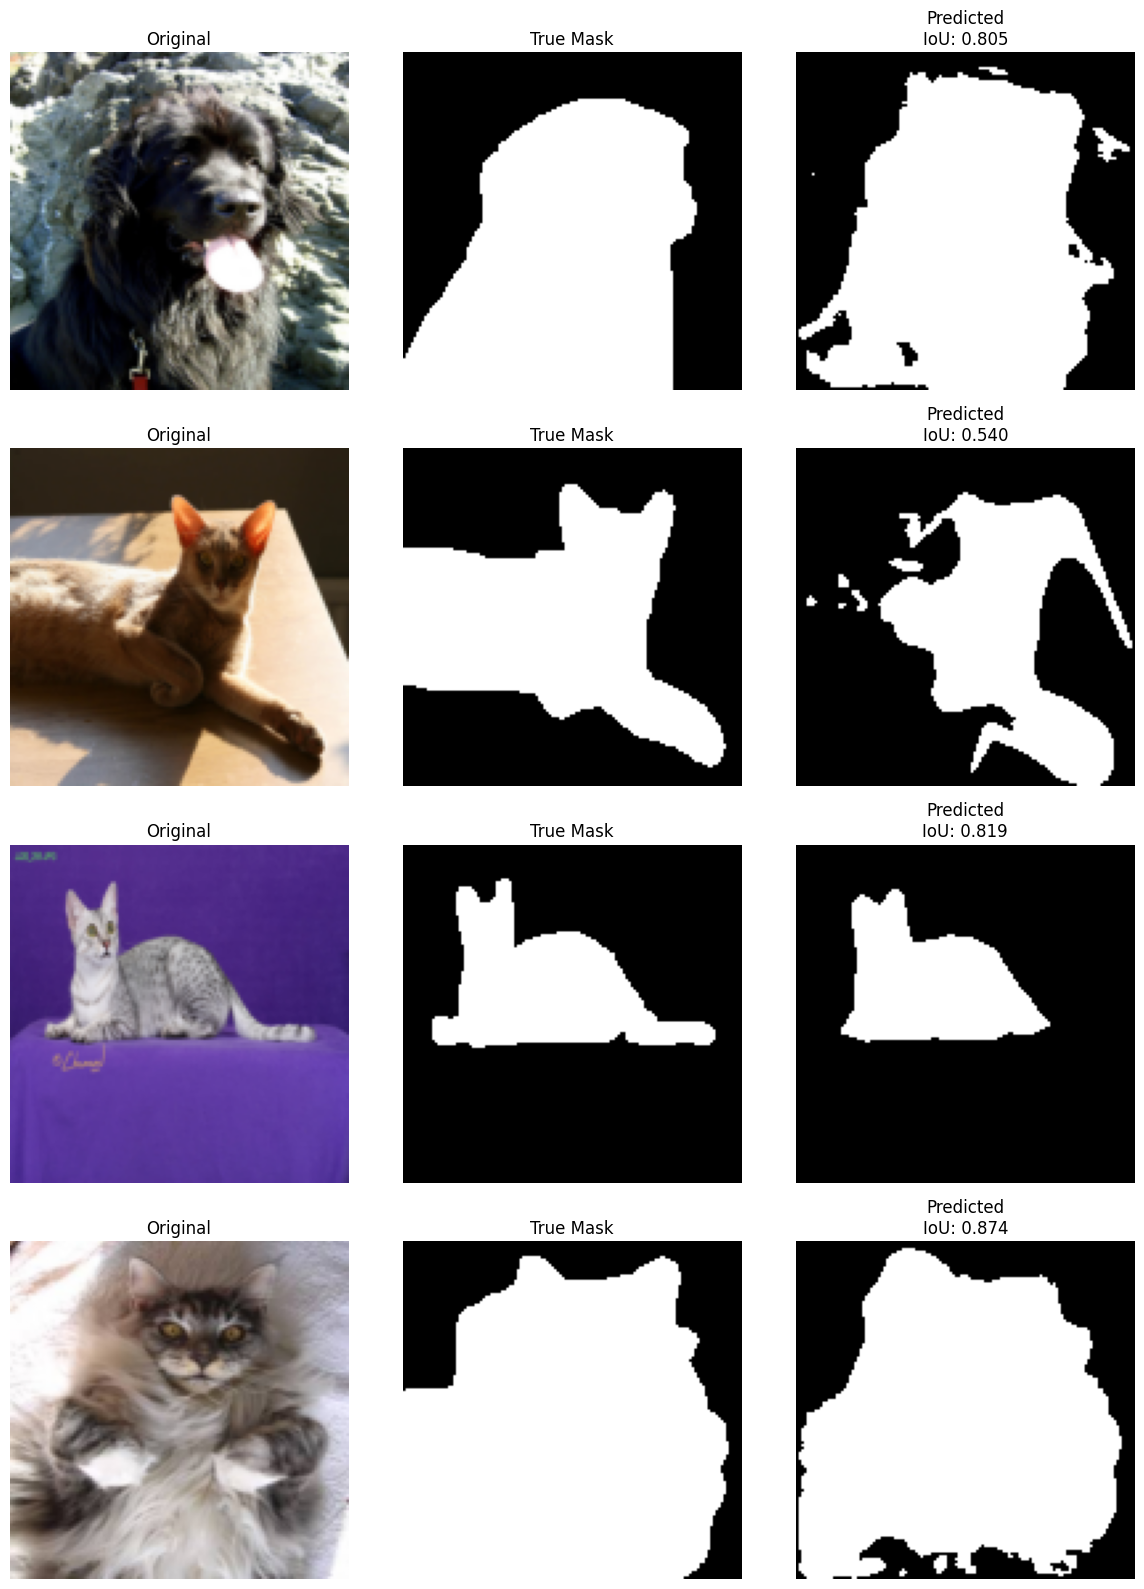

In [17]:
# Final Milestone: Prediction Visualization + Error Analysis

import matplotlib.pyplot as plt

# Load best saved model
best_model = TinyUNet(in_channels=3, num_classes=2, base_channels=32).to(device)
best_model.load_state_dict(torch.load(best_model_path, map_location=device))
best_model.eval()

# Get one validation batch
images, masks = next(iter(val_loader))
images = images.to(device)

# Predict
with torch.inference_mode():
    predictions = best_model(images).argmax(dim=1).cpu()

images = images.cpu()
masks = masks.cpu()

num_examples = min(4, images.shape[0])

plt.figure(figsize=(12, 4 * num_examples))

for i in range(num_examples):
    image = images[i].permute(1, 2, 0)
    true_mask = masks[i]
    pred_mask = predictions[i]

    # Per-image IoU
    intersection = ((pred_mask == 1) & (true_mask == 1)).sum()
    union = ((pred_mask == 1) | (true_mask == 1)).sum().clamp_min(1)
    iou = (intersection.float() / union.float()).item()

    pixel_acc = (pred_mask == true_mask).float().mean().item()

    print(f"Example {i+1}: Pixel Acc = {pixel_acc:.4f}, Foreground IoU = {iou:.4f}")

    plt.subplot(num_examples, 3, i * 3 + 1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(num_examples, 3, i * 3 + 2)
    plt.imshow(true_mask, cmap="gray", vmin=0, vmax=1)
    plt.title("True Mask")
    plt.axis("off")

    plt.subplot(num_examples, 3, i * 3 + 3)
    plt.imshow(pred_mask, cmap="gray", vmin=0, vmax=1)
    plt.title(f"Predicted\nIoU: {iou:.3f}")
    plt.axis("off")

plt.tight_layout()
plt.show()